In [1]:
# 1. KÜTÜPHANELER
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("TensorFlow Versiyonu:", tf.__version__)

# 2. VERİ YÜKLEME VE NORMALİZASYON (FASHION MNIST)
# Veriyi 0-255 piksel değerlerinden 0-1 aralığına çekiyoruz
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

# 3. MODELLERİN İNŞASI
# Model A: Dropout YOK (Korumasız, ezberlemeye müsait devre)
model_overfit = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Model B: Dropout VAR (Ezberlemeyi önleyen, kararlı devre)
model_dropout = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Nöronların %50'sini devre dışı bırakıyoruz
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # İkinci katmanda da aynı koruma
    layers.Dense(10, activation='softmax')
])

# 4. MODELLERİ DERLEME
model_overfit.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_dropout.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Devreler başarıyla kuruldu! Eğitime (enerji vermeye) hazırız.")

TensorFlow Versiyonu: 2.21.0
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 9us/step 
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Devreler başarıyla kuruldu! Eğitime (enerji vermeye) hazırız.


C:\Users\deniz\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [2]:
# 5. MODELLERİN EĞİTİLMESİ (DEVREYE ENERJİ VERİLMESİ)
# İki modeli de 20 epoch (tur) boyunca eğitiyoruz ve sonuçları kaydediyoruz.
# Validation_data kısmı, modelin eğitim sırasında hiç görmediği veride nasıl davrandığını ölçer.

EPOCH_SAYISI = 20

print("1. Devre Eğitiliyor (Korumasız - Overfit Bekleniyor)...")
history_overfit = model_overfit.fit(train_images, train_labels, 
                                    epochs=EPOCH_SAYISI, 
                                    validation_data=(test_images, test_labels),
                                    verbose=1) # verbose=1 ile eğitim adımlarını ekranda görürüz

print("\n-------------------------------------------------\n")

print("2. Devre Eğitiliyor (Korumalı - Dropout)...")
history_dropout = model_dropout.fit(train_images, train_labels, 
                                    epochs=EPOCH_SAYISI, 
                                    validation_data=(test_images, test_labels),
                                    verbose=1)

print("\nEğitimler Tamamlandı! Simülasyon verileri toplandı.")

1. Devre Eğitiliyor (Korumasız - Overfit Bekleniyor)...
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8316 - loss: 0.4657 - val_accuracy: 0.8605 - val_loss: 0.3935
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - accuracy: 0.8675 - loss: 0.3563 - val_accuracy: 0.8634 - val_loss: 0.3803
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - accuracy: 0.8820 - loss: 0.3187 - val_accuracy: 0.8778 - val_loss: 0.3469
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8892 - loss: 0.2973 - val_accuracy: 0.8775 - val_loss: 0.3538
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8952 - loss: 0.2789 - val_accuracy: 0.8822 - val_loss: 0.3402
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.9018 - loss: 0.2621 - val_accuracy: 0.8838 - val_loss: 0.3264
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9046 - loss: 0.2505 - val_accuracy: 0.8842 - val_loss: 0.3357
Epoch 8/20
1875/1875

Grafik 'dropout_kiyaslama_grafigi.png' adıyla Jupyter klasörüne kaydedildi.


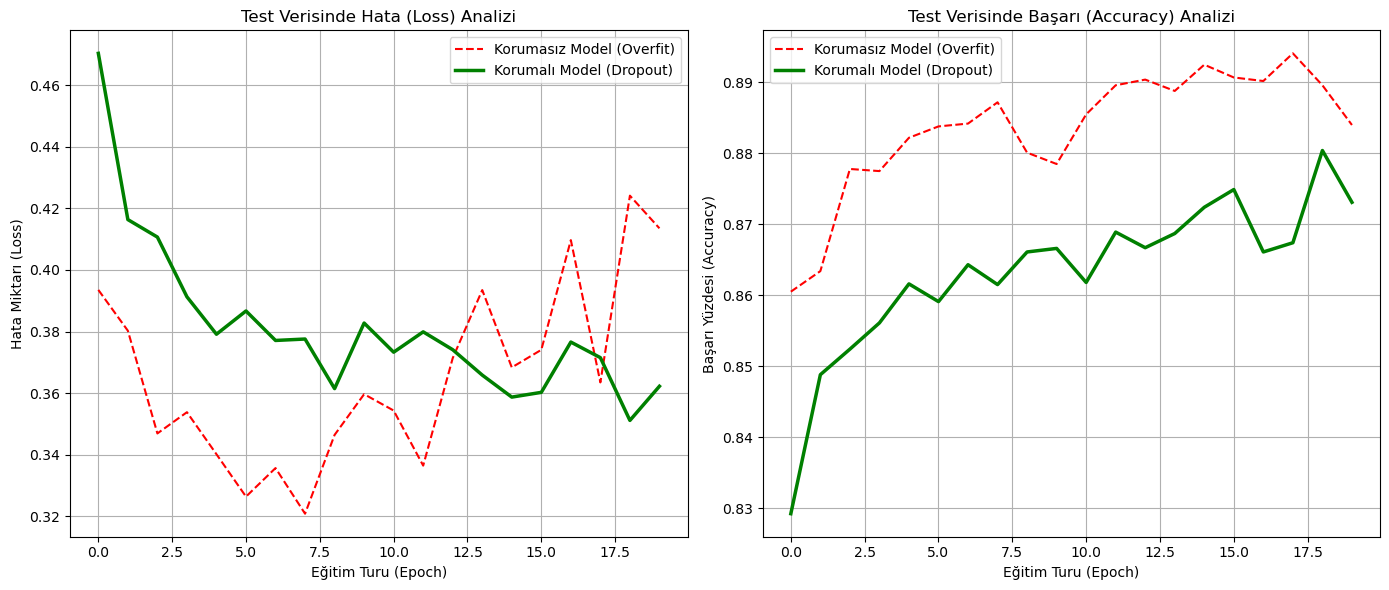

In [4]:
# 6. SONUÇLARIN GÖRSELLEŞTİRİLMESİ (BÜYÜK KIYASLAMA)
# Matplotlib ile test verilerindeki (validation) hata ve başarı oranlarını çizdiriyoruz.

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# --- 1. Grafik: Hata (Loss) Oranı Kıyaslaması ---
# Hatanın DÜŞÜK olması iyidir.
plt.subplot(1, 2, 1)
plt.plot(history_overfit.history['val_loss'], label='Korumasız Model (Overfit)', color='red', linestyle='--')
plt.plot(history_dropout.history['val_loss'], label='Korumalı Model (Dropout)', color='green', linewidth=2.5)
plt.title('Test Verisinde Hata (Loss) Analizi')
plt.xlabel('Eğitim Turu (Epoch)')
plt.ylabel('Hata Miktarı (Loss)')
plt.legend()
plt.grid(True)

# --- 2. Grafik: Başarı (Accuracy) Oranı Kıyaslaması ---
# Başarının YÜKSEK olması iyidir.
plt.subplot(1, 2, 2)
plt.plot(history_overfit.history['val_accuracy'], label='Korumasız Model (Overfit)', color='red', linestyle='--')
plt.plot(history_dropout.history['val_accuracy'], label='Korumalı Model (Dropout)', color='green', linewidth=2.5)
plt.title('Test Verisinde Başarı (Accuracy) Analizi')
plt.xlabel('Eğitim Turu (Epoch)')
plt.ylabel('Başarı Yüzdesi (Accuracy)')
plt.legend()
plt.grid(True)

# Grafikleri ekranda düzgün göstermek için
plt.tight_layout()
# Grafikleri ekranda düzgün göstermek için
plt.tight_layout()

# --- GRAFİĞİ BİLGİSAYARA KAYDETME KODU BURAYA GELECEK ---
plt.savefig('dropout_kiyaslama_grafigi.png', bbox_inches='tight', dpi=300) 
print("Grafik 'dropout_kiyaslama_grafigi.png' adıyla Jupyter klasörüne kaydedildi.")
# -------------------------------------------------------

plt.show()
plt.show()